# Distribuição do Tempo de Atendimento em Central de Atendimento

**Autor:** Wellington M. Santos <br>
**LinkedIn:** https://www.linkedin.com/in/wellington-moreira-santos <br>
**Contato:** wsantos08@hotmail.com


## Contexto

---

Você foi contratado como analista de qualidade por uma central de atendimento que está revisando suas metas de nível de serviço (SLA) para o próximo trimestre. A gerência de operações precisa entender como o tempo de atendimento se distribui entre os diferentes canais de contato antes de definir metas realistas e identificar atendimentos fora do padrão esperado. Sua missão é utilizar **NumPy** para gerar os dados simulados de atendimento e **Pandas** para processá-los, além de **Matplotlib** e **Seaborn** para criar visualizações que ajudem a gerência a compreender a forma da distribuição e tomar decisões sobre as metas de atendimento.

### Objetivos de Aprendizagem

---

Ao final deste exercício, você será capaz de:

- Explorar a distribuição do tempo de atendimento por canal
- Calcular medidas de posição (média, mediana, moda) e dispersão (desvio padrão, coeficiente de variação, quartis)
- Verificar a regra empírica comparando a proporção real de atendimentos dentro de desvios padrão da média
- Agrupar atendimentos por canal para comparar variabilidade
- Filtrar atendimentos fora do padrão esperado com base em percentis e desvio padrão
- Categorizar atendimentos por faixa de tempo com `pd.cut()`
- Criar visualizações que evidenciem a forma e a dispersão da distribuição

### Competências a Serem Desenvolvidas

---

- Geração de dados sintéticos com NumPy a partir de uma distribuição estatística
- Cálculo de medidas de posição e dispersão com Pandas e NumPy
- Verificação da regra empírica (68-95-99.7) em uma amostra real
- Agrupamento de dados por canal de atendimento com `groupby()`
- Categorização de atendimentos com `pd.cut()` e manipulação de datas com `pd.to_datetime()`
- Construção de gráficos com Matplotlib e Seaborn (histograma, boxplot, barras, pizza e heatmap)

## Tarefas

### 1. Importações e Configurações Iniciais

In [1]:
# bibliotecas
import session_info
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# configuração de estilo para visualizações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# configuração para dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

session_info.show(dependencies=False)

### 2. Conjunto de Dados

Gere um DataFrame utilizando NumPy para simular os dados de atendimento:

**Descrição das Colunas:**

- `Atendimento_ID`: Identificador único do atendimento
- `Canal`: Canal utilizado pelo cliente para contato (Telefone, Chat, E-mail, Presencial)
- `Tempo_Atendimento_Min`: Duração do atendimento em minutos, gerada a partir de uma distribuição gamma, que produz uma cauda assimétrica à direita, comportamento comum em tempos de atendimento
- `Satisfacao_Cliente`: Nota de satisfação do cliente após o atendimento, em escala de 1 a 5
- `Data_Atendimento`: Data em que o atendimento ocorreu

---

In [2]:
np.random.seed(42)

In [3]:
atendimento_id = np.arange(1, 13)
atendimento_id

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [4]:
canal = np.random.choice(
    ['Telefone', 'Chat', 'E-mail', 'Presencial'],
    size=12,
    p=[0.35, 0.30, 0.20, 0.15]
)
canal

array(['Chat', 'Presencial', 'E-mail', 'Chat', 'Telefone', 'Telefone',
       'Telefone', 'Presencial', 'Chat', 'E-mail', 'Telefone',
       'Presencial'], dtype='<U10')

In [5]:
tempo_atendimento_min = np.round(np.random.gamma(shape=2.5, scale=4, size=12), 1)
tempo_atendimento_min

array([ 6.2, 12.3, 10.2,  1.6,  4. , 10.7, 20.5,  7.4,  5.8,  9.3,  5.6,
        7.1])

In [6]:
satisfacao_cliente = np.random.choice(
    [1, 2, 3, 4, 5],
    size=12,
    p=[0.05, 0.10, 0.20, 0.35, 0.30]
)
satisfacao_cliente

array([2, 4, 1, 5, 3, 4, 3, 4, 4, 3, 5, 5])

In [7]:
data_atendimento = pd.date_range(start='2026-03-01', periods=12, freq='2D').strftime('%Y-%m-%d')
data_atendimento

Index(['2026-03-01', '2026-03-03', '2026-03-05', '2026-03-07', '2026-03-09',
       '2026-03-11', '2026-03-13', '2026-03-15', '2026-03-17', '2026-03-19',
       '2026-03-21', '2026-03-23'],
      dtype='str')

In [8]:
dados = {
    'Atendimento_ID': atendimento_id,
    'Canal': canal,
    'Tempo_Atendimento_Min': tempo_atendimento_min,
    'Satisfacao_Cliente': satisfacao_cliente,
    'Data_Atendimento': data_atendimento
}
dados

{'Atendimento_ID': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 'Canal': array(['Chat', 'Presencial', 'E-mail', 'Chat', 'Telefone', 'Telefone',
        'Telefone', 'Presencial', 'Chat', 'E-mail', 'Telefone',
        'Presencial'], dtype='<U10'),
 'Tempo_Atendimento_Min': array([ 6.2, 12.3, 10.2,  1.6,  4. , 10.7, 20.5,  7.4,  5.8,  9.3,  5.6,
         7.1]),
 'Satisfacao_Cliente': array([2, 4, 1, 5, 3, 4, 3, 4, 4, 3, 5, 5]),
 'Data_Atendimento': Index(['2026-03-01', '2026-03-03', '2026-03-05', '2026-03-07', '2026-03-09',
        '2026-03-11', '2026-03-13', '2026-03-15', '2026-03-17', '2026-03-19',
        '2026-03-21', '2026-03-23'],
       dtype='str')}

In [9]:
df = pd.DataFrame(dados)

### 3. Exploração Inicial

- Exibir as cinco primeiras linhas do DataFrame  
    _Dica: Utilize um método que permite visualizar as primeiras entradas de um DataFrame._
    
- Verificar a existência de valores ausentes  
    _Dica: Explore funções que ajudam a identificar dados nulos em cada coluna._
    
- Apresentar estatísticas descritivas das colunas `Tempo_Atendimento_Min` e `Satisfacao_Cliente`  
    _Dica: Utilize métodos que geram resumos estatísticos para colunas numéricas._
    
- **Visualização**: Criar um histograma do `Tempo_Atendimento_Min` com curva de densidade  
    _Dica: Use sns.histplot() com o parâmetro kde=True para observar a forma da distribuição._
    

---

In [10]:
# primeiras linhas
df.head()

,Atendimento_ID,Canal,Tempo_Atendimento_Min,Satisfacao_Cliente,Data_Atendimento
0,1,Chat,6.20,2,2026-03-01
1,2,Presencial,12.30,4,2026-03-03
2,3,E-mail,10.20,1,2026-03-05
3,4,Chat,1.60,5,2026-03-07
4,5,Telefone,4.00,3,2026-03-09


In [11]:
# check null
df.isna().sum()

Atendimento_ID           0
Canal                    0
Tempo_Atendimento_Min    0
Satisfacao_Cliente       0
Data_Atendimento         0
dtype: int64

In [12]:
# describe :: Tempo_Atendimento_Min, Satisfacao_Cliente
df[["Tempo_Atendimento_Min", "Satisfacao_Cliente"]].describe()

,Tempo_Atendimento_Min,Satisfacao_Cliente
count,12.00,12.00
mean,8.39,3.58
std,4.85,1.24
min,1.60,1.00
25%,5.75,3.00
50%,7.25,4.00
75%,10.32,4.25
max,20.50,5.00


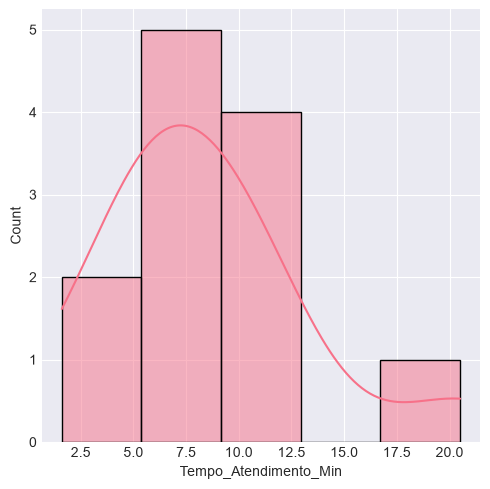

In [13]:
# histograma de Tempo_Atendimento_Min com kde
sns.displot(df['Tempo_Atendimento_Min'], kde=True);

### 4. Cálculos Básicos

- Calcular a média, a mediana e a moda do `Tempo_Atendimento_Min`  
    _Dica: Utilize mean(), median() e mode() do Pandas ou funções equivalentes do NumPy._
    
- Calcular o desvio padrão, a variância e o coeficiente de variação do `Tempo_Atendimento_Min`  
    _Dica: O coeficiente de variação é a razão entre o desvio padrão e a média, geralmente expresso em percentual._
    
- Calcular o primeiro quartil (Q1), o terceiro quartil (Q3) e a amplitude interquartil (IQR) de `Tempo_Atendimento_Min`  
    _Dica: Utilize quantile() para os quartis e subtraia Q1 de Q3 para obter o IQR._
    
- **Visualização**: Criar um boxplot do `Tempo_Atendimento_Min`  
    _Dica: Use sns.boxplot() para visualizar quartis, mediana e possíveis outliers em um único gráfico._
    

---

In [14]:
# media moda mediana :: Tempo_Atendimento_Min
df['Tempo_Atendimento_Min'].mean(), df['Tempo_Atendimento_Min'].median(), df['Tempo_Atendimento_Min'].mode()

(np.float64(8.391666666666664),
 np.float64(7.25),
 0     1.60
 1     4.00
 2     5.60
 3     5.80
 4     6.20
 5     7.10
 6     7.40
 7     9.30
 8    10.20
 9    10.70
 10   12.30
 11   20.50
 Name: Tempo_Atendimento_Min, dtype: float64)

In [15]:
# check ausencia de moda
df['Tempo_Atendimento_Min'].value_counts()

Tempo_Atendimento_Min
6.20     1
12.30    1
10.20    1
1.60     1
4.00     1
10.70    1
20.50    1
7.40     1
5.80     1
9.30     1
5.60     1
7.10     1
Name: count, dtype: int64

In [16]:
# desvio variancia e coef :: Tempo_Atendimento_Min
df['Tempo_Atendimento_Min'].std(), df['Tempo_Atendimento_Min'].var(), f'{df['Tempo_Atendimento_Min'].std()/df['Tempo_Atendimento_Min'].mean():.2%}'

(np.float64(4.849453265028643), np.float64(23.51719696969697), '57.79%')

In [17]:
# Q1 Q3 IQR
q3, q1 = np.percentile(df['Tempo_Atendimento_Min'], [75, 25])
iqr = q3 - q1

q1, q3, iqr

(np.float64(5.75), np.float64(10.325), np.float64(4.574999999999999))

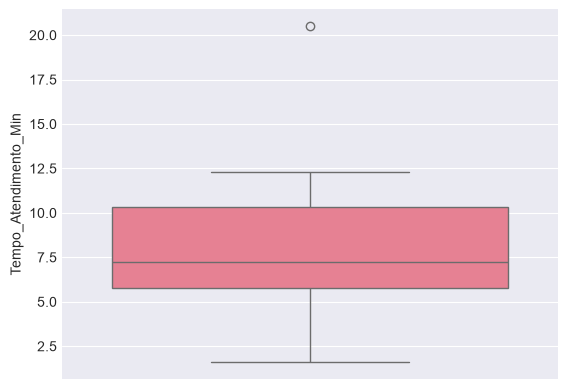

In [18]:
# boxplot :: Tempo_Atendimento_Min
sns.boxplot(df['Tempo_Atendimento_Min']);

### 5. Análise por Agrupamento

- Agrupar os dados por `Canal` e calcular a média e o desvio padrão do `Tempo_Atendimento_Min`  
    _Dica: Utilize groupby() seguido de agg() com múltiplas funções de agregação._
    
- Identificar qual canal apresenta maior coeficiente de variação, ou seja, maior instabilidade no tempo de atendimento  
    _Dica: Calcule o coeficiente de variação por grupo dividindo o desvio padrão pela média de cada canal._
    
- Agrupar os dados por `Canal` e calcular a média de `Satisfacao_Cliente`  
    _Dica: Use o mesmo método de agrupamento, alterando apenas a coluna de agregação._
    
- **Visualização**: Criar um gráfico de barras com Matplotlib mostrando o tempo médio de atendimento por `Canal`  
    _Dica: Use plt.bar() ou o método plot(kind='bar') sobre o resultado do groupby()._
    

---

In [19]:
# group :: Tempo_Atendimento_Min por Canal -> media desvio
group_canal = df.groupby('Canal')['Tempo_Atendimento_Min'].agg({'mean','std'})
group_canal

,std,mean
Canal,,
Chat,2.55,4.53
E-mail,0.64,9.75
Presencial,2.92,8.93
Telefone,7.44,10.20


In [20]:
# maior coef de var
group_canal['coef'] = group_canal['std'] / group_canal['mean']
group_canal

,std,mean,coef
Canal,,,
Chat,2.55,4.53,0.56
E-mail,0.64,9.75,0.07
Presencial,2.92,8.93,0.33
Telefone,7.44,10.20,0.73


In [21]:
group_canal.nlargest(1, 'coef')

,std,mean,coef
Canal,,,
Telefone,7.44,10.20,0.73


In [22]:
# group :: Canal mean  Satisfacao_Cliente
df.groupby('Canal')['Satisfacao_Cliente'].mean()

Canal
Chat         3.67
E-mail       2.00
Presencial   4.33
Telefone     3.75
Name: Satisfacao_Cliente, dtype: float64

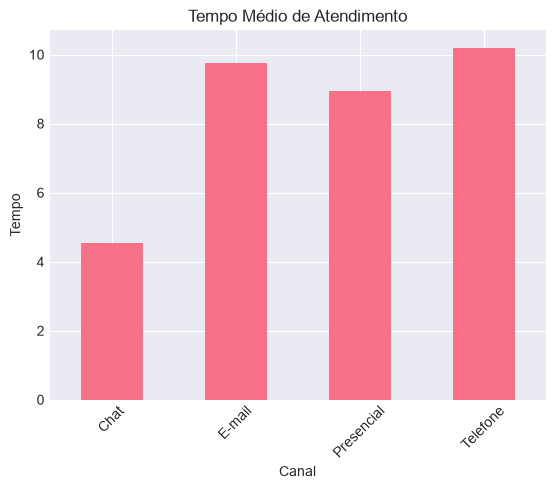

In [23]:
# barplot :: tempo medio de atendimento por Canal
group_canal['mean'].plot(kind='bar', 
                        title='Tempo Médio de Atendimento',
                        ylabel='Tempo',
                        rot=45);

### 6. Aplicação de Filtros

- Filtrar os atendimentos com `Tempo_Atendimento_Min` acima do percentil 90  
    _Dica: Calcule o percentil 90 com quantile(0.9) e utilize esse valor como condição de filtro._
    
- Contar quantos atendimentos estão dentro de um desvio padrão da média (entre média - desvio e média + desvio) e calcular o percentual sobre o total  
    _Dica: Utilize expressões booleanas combinadas com & para verificar o intervalo, depois compare esse percentual com o valor teórico de aproximadamente 68% previsto pela regra empírica._
    
- Filtrar os atendimentos do canal "Telefone" com `Satisfacao_Cliente` menor ou igual a 2  
    _Dica: Combine múltiplas condições usando o operador & (E)._
    
- **Visualização**: Criar um gráfico de pizza com Matplotlib mostrando a proporção de atendimentos dentro e fora de um desvio padrão da média  
    _Dica: Use plt.pie() com os dois grupos calculados na tarefa anterior e adicione percentuais com autopct='%1.1f%%'._
    

---

In [74]:
# Tempo_Atendimento_Min > q90
p90 = df['Tempo_Atendimento_Min'].quantile(.9)
atendimentos_acima_p90 = df.query('Tempo_Atendimento_Min > @p90')

print(f"\nPercentil 90: {p90:.2f} min")
print(f"Atendimentos acima do percentil 90 ({len(atendimentos_acima_p90)} registros):")


Percentil 90: 12.14 min
Atendimentos acima do percentil 90 (2 registros):


In [37]:
atendimentos_acima_p90

,Atendimento_ID,Canal,Tempo_Atendimento_Min,Satisfacao_Cliente,Data_Atendimento
1,2,Presencial,12.30,4,2026-03-03
6,7,Telefone,20.50,3,2026-03-13


In [42]:
# atendimentos no limite
media         = df['Tempo_Atendimento_Min'].mean()
desvio_padrao = df['Tempo_Atendimento_Min'].std()

media, desvio_padrao

(np.float64(8.391666666666664), np.float64(4.849453265028643))

In [41]:
limite_inferior = media - desvio_padrao
limite_superior = media + desvio_padrao

limite_inferior, limite_superior

(np.float64(3.542213401638021), np.float64(13.241119931695307))

In [43]:
dentro_1dp = df[
    (df['Tempo_Atendimento_Min'] >= limite_inferior) &
    (df['Tempo_Atendimento_Min'] <= limite_superior)
]

dentro_1dp

,Atendimento_ID,Canal,Tempo_Atendimento_Min,Satisfacao_Cliente,Data_Atendimento
0,1,Chat,6.20,2,2026-03-01
1,2,Presencial,12.30,4,2026-03-03
2,3,E-mail,10.20,1,2026-03-05
4,5,Telefone,4.00,3,2026-03-09
5,6,Telefone,10.70,4,2026-03-11
7,8,Presencial,7.40,4,2026-03-15
8,9,Chat,5.80,4,2026-03-17
9,10,E-mail,9.30,3,2026-03-19
10,11,Telefone,5.60,5,2026-03-21
11,12,Presencial,7.10,5,2026-03-23


In [55]:
percentual_dentro_1dp = (len(dentro_1dp) / len(df)) * 100
percentual_dentro_1dp

83.33333333333334

In [56]:
print("Valor teórico esperado pela regra empírica: ~68%")
print(f"Diferença em relação ao teórico: {percentual_dentro_1dp - 68:.1f} pontos percentuais")

Valor teórico esperado pela regra empírica: ~68%
Diferença em relação ao teórico: 15.3 pontos percentuais


In [57]:
# satisfação dos clientes
telefone_insatisfeitos = df[(df['Canal'] == 'Telefone') & (df['Satisfacao_Cliente'] <= 2)]
print(f"\nAtendimentos por telefone com satisfação <= 2 ({len(telefone_insatisfeitos)} registros):")


Atendimentos por telefone com satisfação <= 2 (0 registros):


In [58]:
telefone_insatisfeitos

,Atendimento_ID,Canal,Tempo_Atendimento_Min,Satisfacao_Cliente,Data_Atendimento


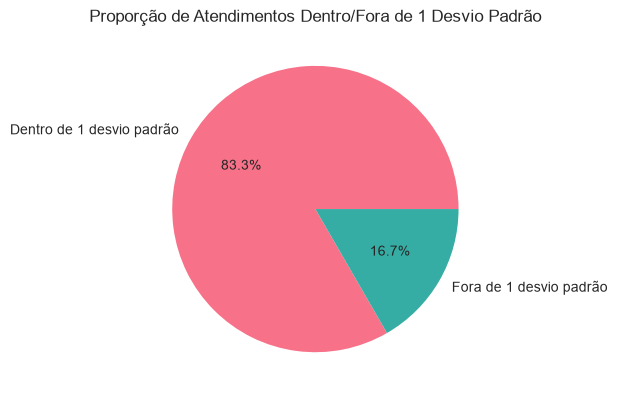

In [48]:
# viz :: pie proporção 
fora_1dp = len(df) - len(dentro_1dp)
plt.figure(figsize=(6, 6))
plt.pie(
    [len(dentro_1dp), fora_1dp],
    labels=['Dentro de 1 desvio padrão', 'Fora de 1 desvio padrão'],
    autopct='%1.1f%%',
    colors=sns.color_palette('husl', 2)
)
plt.title('Proporção de Atendimentos Dentro/Fora de 1 Desvio Padrão')
plt.tight_layout()
plt.show()

### 7. Extra (Desafio)

- Converter a coluna `Data_Atendimento` para o formato datetime e extrair o dia da semana  
    _Dica: Utilize pd.to_datetime() e o atributo dt.day_name()._
    
- Criar uma nova coluna `Faixa_Tempo` que classifique os atendimentos como "Rápido" (até 5 min), "Moderado" (5 a 10 min), "Lento" (10 a 15 min) ou "Crítico" (acima de 15 min)  
    _Dica: Utilize pd.cut() com bins apropriados e labels personalizados._
    
- Calcular a diferença percentual entre a média e a mediana do `Tempo_Atendimento_Min` e discutir se a distribuição é assimétrica à direita ou à esquerda  
    _Dica: Uma média maior que a mediana geralmente indica assimetria à direita, causada por valores extremos superiores._
    
- Calcular o z-score de cada atendimento e identificar os atendimentos atípicos, considerando \|z\| maior que 2  
    _Dica: O z-score é calculado como (valor - média) / desvio padrão._
    
- **Visualização**: Criar um heatmap com Seaborn mostrando a correlação entre `Tempo_Atendimento_Min` e `Satisfacao_Cliente`  
    _Dica: Use df.corr() para calcular a matriz de correlação e sns.heatmap() com annot=True para visualizar._
    

---

In [59]:
# converter p/datetime
df['Data_Atendimento'] = pd.to_datetime(df['Data_Atendimento'])
df.dtypes

Atendimento_ID                    int64
Canal                               str
Tempo_Atendimento_Min           float64
Satisfacao_Cliente                int64
Data_Atendimento         datetime64[us]
dtype: object

In [62]:
# dia da semana
df['Dia_Semana'] = df['Data_Atendimento'].dt.day_name(locale='pt_BR')

In [63]:
df

,Atendimento_ID,Canal,Tempo_Atendimento_Min,Satisfacao_Cliente,Data_Atendimento,Dia_Semana
0,1,Chat,6.20,2,2026-03-01,Domingo
1,2,Presencial,12.30,4,2026-03-03,Terça-feira
2,3,E-mail,10.20,1,2026-03-05,Quinta-feira
3,4,Chat,1.60,5,2026-03-07,Sábado
4,5,Telefone,4.00,3,2026-03-09,Segunda-feira
5,6,Telefone,10.70,4,2026-03-11,Quarta-feira
6,7,Telefone,20.50,3,2026-03-13,Sexta-feira
7,8,Presencial,7.40,4,2026-03-15,Domingo
8,9,Chat,5.80,4,2026-03-17,Terça-feira
9,10,E-mail,9.30,3,2026-03-19,Quinta-feira


In [65]:
# faixas ::  "Rápido" (até 5 min), "Moderado" (5 a 10 min), "Lento" (10 a 15 min) ou "Crítico" (acima de 15 min)
bins = [0, 5, 10, 15, np.inf]
labels = ['Rápido', 'Moderado', 'Lento', 'Crítico']
df['Faixa_Tempo'] = pd.cut(df['Tempo_Atendimento_Min'], bins=bins, labels=labels)
df

,Atendimento_ID,Canal,Tempo_Atendimento_Min,Satisfacao_Cliente,Data_Atendimento,Dia_Semana,Faixa_Tempo
0,1,Chat,6.20,2,2026-03-01,Domingo,Moderado
1,2,Presencial,12.30,4,2026-03-03,Terça-feira,Lento
2,3,E-mail,10.20,1,2026-03-05,Quinta-feira,Lento
3,4,Chat,1.60,5,2026-03-07,Sábado,Rápido
4,5,Telefone,4.00,3,2026-03-09,Segunda-feira,Rápido
5,6,Telefone,10.70,4,2026-03-11,Quarta-feira,Lento
6,7,Telefone,20.50,3,2026-03-13,Sexta-feira,Crítico
7,8,Presencial,7.40,4,2026-03-15,Domingo,Moderado
8,9,Chat,5.80,4,2026-03-17,Terça-feira,Moderado
9,10,E-mail,9.30,3,2026-03-19,Quinta-feira,Moderado


In [66]:
df['Faixa_Tempo'].value_counts().sort_index()

Faixa_Tempo
Rápido      2
Moderado    6
Lento       3
Crítico     1
Name: count, dtype: int64

In [69]:
# diff percentual :: Tempo_Atendimento_Min
mediana         = df['Tempo_Atendimento_Min'].median()
diff_percentual = ((media - mediana) / mediana) * 100
diff_percentual

np.float64(15.747126436781572)

In [70]:
# assimetria :: Tempo_Atendimento_Min
direcao_assimetria = "à direita" if media > mediana else "à esquerda"

print(f"A distribuição é assimétrica {direcao_assimetria}, pois a média é "
      f"{'maior' if media > mediana else 'menor'} que a mediana.")

A distribuição é assimétrica à direita, pois a média é maior que a mediana.


In [71]:
# atipicos com dados > 2 :: escala Z (valor - média) / desvio padrão.
df['Z_Score'] = (df['Tempo_Atendimento_Min'] - media) / desvio_padrao
df

,Atendimento_ID,Canal,Tempo_Atendimento_Min,Satisfacao_Cliente,Data_Atendimento,Dia_Semana,Faixa_Tempo,Z_Score
0,1,Chat,6.20,2,2026-03-01,Domingo,Moderado,-0.45
1,2,Presencial,12.30,4,2026-03-03,Terça-feira,Lento,0.81
2,3,E-mail,10.20,1,2026-03-05,Quinta-feira,Lento,0.37
3,4,Chat,1.60,5,2026-03-07,Sábado,Rápido,-1.40
4,5,Telefone,4.00,3,2026-03-09,Segunda-feira,Rápido,-0.91
5,6,Telefone,10.70,4,2026-03-11,Quarta-feira,Lento,0.48
6,7,Telefone,20.50,3,2026-03-13,Sexta-feira,Crítico,2.50
7,8,Presencial,7.40,4,2026-03-15,Domingo,Moderado,-0.20
8,9,Chat,5.80,4,2026-03-17,Terça-feira,Moderado,-0.53
9,10,E-mail,9.30,3,2026-03-19,Quinta-feira,Moderado,0.19


In [72]:
atipicos = df[df['Z_Score'].abs() > 2]
atipicos

,Atendimento_ID,Canal,Tempo_Atendimento_Min,Satisfacao_Cliente,Data_Atendimento,Dia_Semana,Faixa_Tempo,Z_Score
6,7,Telefone,20.50,3,2026-03-13,Sexta-feira,Crítico,2.50


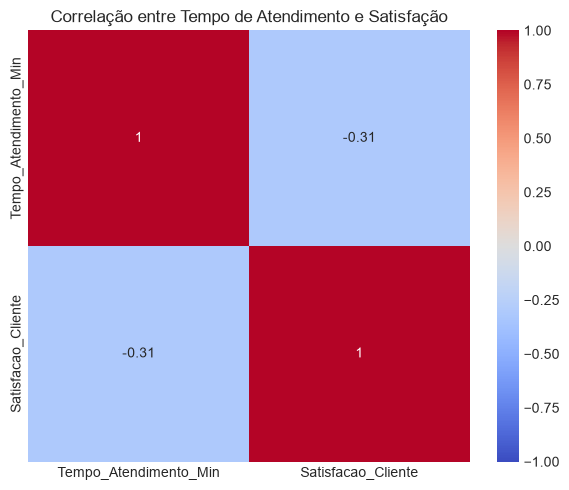

In [73]:
# viz :: heatmap de corr
plt.figure(figsize=(6, 5))
correlacao = df[['Tempo_Atendimento_Min', 'Satisfacao_Cliente']].corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação entre Tempo de Atendimento e Satisfação')
plt.tight_layout()
plt.show()

### 8. Reflexão e Perguntas Adicionais

Após concluir as tarefas, reflita sobre os seguintes pontos:

- **Padrões Identificados**: Qual canal apresentou maior tempo médio de atendimento? Existe relação entre o tempo de atendimento e a satisfação do cliente?

- **Qualidade dos Dados**: Os dados gerados representam um cenário realista? Como uma amostra maior mudaria a confiabilidade das medidas calculadas?
    
- **Insights para o Negócio**: Com base na sua análise, qual meta de SLA você recomendaria, e para quais canais? Algum canal precisa de atenção prioritária?
    
- **Próximos Passos**: Que outras análises poderiam ser realizadas? Pense em amostras maiores, comparação entre períodos ou testes formais de normalidade.
    
- **Visualizações**: As visualizações comunicam claramente a forma da distribuição e a variabilidade entre canais? Qual gráfico foi mais efetivo para identificar atendimentos fora do padrão?
    
- **Média x Mediana**: Considerando a assimetria observada na distribuição, qual medida de posição, média ou mediana, é mais adequada para representar o tempo típico de atendimento e servir de referência para a meta de SLA?
    

>O canal Telefone se destaca por ter o maior tempo médio de atendimento (10,20 min) e a maior instabilidade (73% de coeficiente de variação), puxado pelo atendimento de 20,5 min que aparece como outlier tanto no boxplot quanto no z-score, enquanto a correlação entre tempo e satisfação é fraca e negativa (≈ -0,31); esses resultados vêm de uma amostra sintética plausível mas com grupos por canal muito pequenos (2 a 4 registros), o que torna médias e desvios por canal sensíveis a um único valor e reforça que a mediana (7,25 min), não a média (8,39 min, inflada pelo mesmo outlier), é a referência mais justa para definir metas de SLA por canal, priorizando o Telefone; como próximos passos, valeria ampliar a amostra, validar a assimetria observada com um teste de Shapiro-Wilk formal e explorar a coluna de dia da semana já extraída mas ainda não analisada, e substituir o heatmap, pouco informativo com n=12, por um scatterplot de Tempo x Satisfação colorido por Canal.

---

## Recursos Adicionais

---

Para aprofundar seus conhecimentos em estatística descritiva e distribuições:

- **Documentação do Pandas**: https://pandas.pydata.org/docs/
- **Documentação do NumPy (Random)**: https://numpy.org/doc/stable/reference/random/index.html
- **Documentação do Seaborn**: https://seaborn.pydata.org/
- **Documentação do Matplotlib**: https://matplotlib.org/stable/contents.html
- **Tutoriais de Análise de Dados**: Explore cursos online e notebooks no Kaggle sobre estatística descritiva

---

## Vocabulário Técnico

---

- **Assimetria (Skewness)**: Grau em que uma distribuição se desvia da simetria. Quando a média é maior que a mediana, a distribuição tende a ser assimétrica à direita.
- **Coeficiente de Variação**: Razão entre o desvio padrão e a média, usada para comparar a dispersão relativa entre grupos com escalas diferentes.
- **Amplitude Interquartil (IQR)**: Diferença entre o terceiro e o primeiro quartil, usada como medida de dispersão resistente a valores extremos.
- **Regra Empírica**: Para distribuições aproximadamente normais, cerca de 68% dos valores estão a um desvio padrão da média, 95% a dois desvios e 99,7% a três desvios.
- **Z-score**: Medida padronizada que indica quantos desvios padrão um valor está distante da média.